In [1]:
#Import and install necessary packages
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
#Load data from file directory
mortality_socio_22_non_f = pd.read_csv("/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 8/mortality_socio_22_non_f.csv")

In [3]:
#Setting up data for modelling
predictors = ['gdp_per_capita', 'health_exp_pct_gdp', 'dtp3_immunization_pct', 'basic_sanitation_pct']
target = 'per_1000'

# Fit on CAR-excluded data (our validated primary model for this analysis) ---
df_no_car = mortality_socio_22_non_f[mortality_socio_22_non_f['entity'] != 'Central African Republic'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_no_car[predictors]),
    columns=predictors,
    index=df_no_car.index
)
X_scaled = sm.add_constant(X_scaled)
y = df_no_car[target]

model = sm.OLS(y, X_scaled).fit()

In [4]:
# Actual minus predicted
df_no_car['predicted_mortality'] = model.fittedvalues
df_no_car['residual'] = df_no_car[target] - df_no_car['predicted_mortality']
# residual = actual - predicted, same convention as model.resid

# Top over-performers (most negative residual = did much better than expected)
overperformers = df_no_car.sort_values('residual').head(10)
print("=== TOP 10 OVER-PERFORMERS (better than model predicts) ===")
print(overperformers[['entity', 'per_1000', 'predicted_mortality', 'residual', 'gdp_per_capita']])

# Top under-performers (most positive residual = did much worse than expected)
underperformers = df_no_car.sort_values('residual', ascending=False).head(10)
print("\n=== TOP 10 UNDER-PERFORMERS (worse than model predicts) ===")
print(underperformers[['entity', 'per_1000', 'predicted_mortality', 'residual', 'gdp_per_capita']])

=== TOP 10 OVER-PERFORMERS (better than model predicts) ===
                    entity   per_1000  predicted_mortality   residual  \
120       Papua New Guinea  41.862140            79.381693 -37.519553   
139        Solomon Islands  21.281724            58.701085 -37.419361   
165                Vanuatu  17.787414            53.083260 -35.295846   
131  Sao Tome and Principe  14.719887            47.224050 -32.504163   
111              Nicaragua  14.284388            45.052210 -30.767822   
49                 Eritrea  36.585634            63.653977 -27.068343   
59                   Ghana  38.643615            60.432532 -21.788917   
19                 Bolivia  17.259605            37.004191 -19.744586   
149               Tanzania  40.114500            59.673175 -19.558675   
158                 Uganda  49.981890            66.888526 -16.906636   

     gdp_per_capita  
120     3102.294097  
139     1877.781045  
165     3679.535243  
131     2389.737298  
111     2322.890696  
49  

In [5]:
# Save full ranked table for your report/GitHub
ranked = df_no_car[['entity', 'per_1000', 'predicted_mortality', 'residual', 'gdp_per_capita', 'income_level', 'regions']]
ranked = ranked.sort_values('residual')
ranked.to_csv("week2_day5_residual_ranking.csv", index=False)
print(f"\nFull ranking saved: {ranked.shape[0]} countries")

# Note CAR separately, since it's excluded from the model above
car_row = mortality_socio_22_non_f[mortality_socio_22_non_f['entity'] == 'Central African Republic']
print("\n=== Central African Republic (excluded from model, reported separately) ===")
print(f"Actual mortality: {car_row['per_1000'].values[0]:.1f} per 1,000 — "
      f"far above what its indicators would predict; treated as an extreme "
      f"outlier case (see Day 3 Cook's Distance analysis) rather than ranked "
      f"alongside the rest.")


Full ranking saved: 167 countries

=== Central African Republic (excluded from model, reported separately) ===
Actual mortality: 424.6 per 1,000 — far above what its indicators would predict; treated as an extreme outlier case (see Day 3 Cook's Distance analysis) rather than ranked alongside the rest.


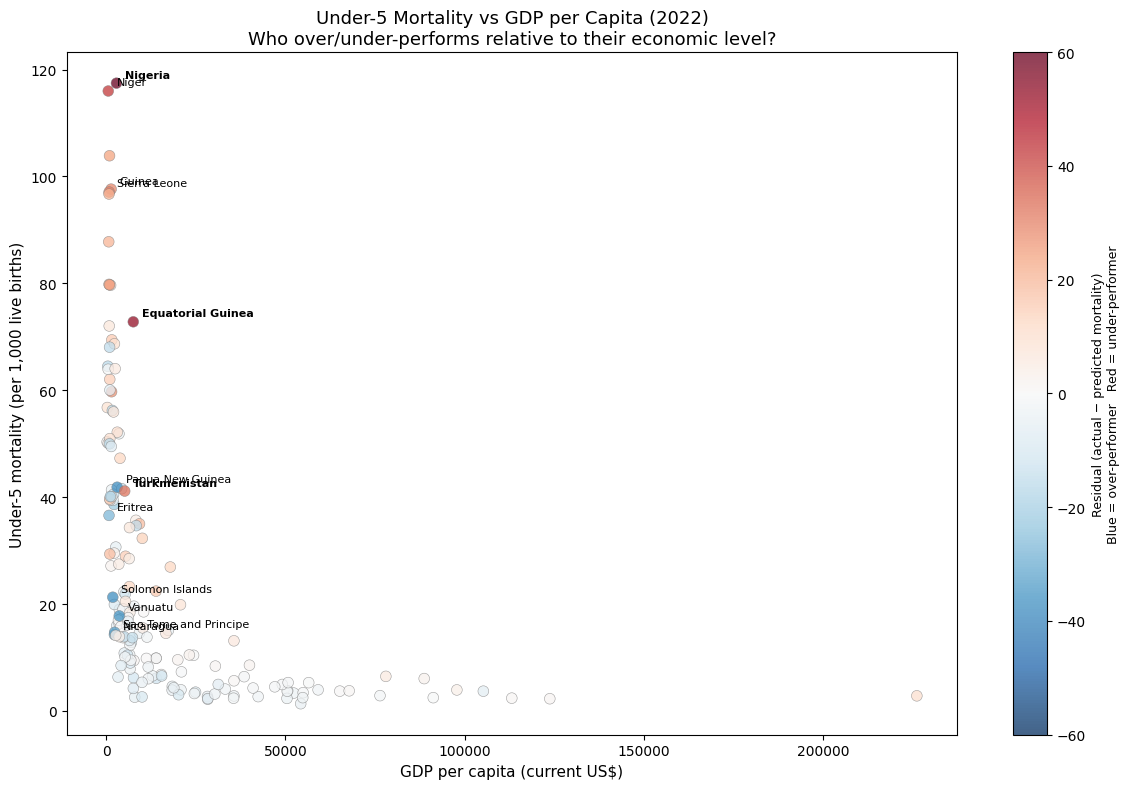

In [6]:
# df_no_car and model should already exist from day5_residual_analysis.py

fig, ax = plt.subplots(figsize=(12, 8))

# Base scatter: all countries, colored by residual
scatter = ax.scatter(
    df_no_car['gdp_per_capita'],
    df_no_car['per_1000'],
    c=df_no_car['residual'],
    cmap='RdBu_r',       # red = underperform (positive residual), blue = overperform
    vmin=-60, vmax=60,   # center the color scale on zero
    s=60,
    alpha=0.75,
    edgecolors='grey',
    linewidths=0.4,
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Residual (actual − predicted mortality)\nBlue = over-performer   Red = under-performer', fontsize=9)

# --- Label the most extreme over/under-performers ---
top_over = df_no_car.sort_values('residual').head(6)
top_under = df_no_car.sort_values('residual', ascending=False).head(6)
label_set = pd.concat([top_over, top_under])

for _, row in label_set.iterrows():
    ax.annotate(
        row['entity'],
        (row['gdp_per_capita'], row['per_1000']),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
        fontweight='bold' if row['entity'] in ['Nigeria', 'Equatorial Guinea', 'Turkmenistan'] else 'normal',
    )

ax.set_xlabel('GDP per capita (current US$)', fontsize=11)
ax.set_ylabel('Under-5 mortality (per 1,000 live births)', fontsize=11)
ax.set_title(
    'Under-5 Mortality vs GDP per Capita (2022)\n'
    'Who over/under-performs relative to their economic level?',
    fontsize=13
)

plt.tight_layout()
plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 12'}/week2_day5_headline_chart.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
print(df_no_car[df_no_car['gdp_per_capita'] > 200000][['entity', 'gdp_per_capita', 'per_1000']])

     entity  gdp_per_capita  per_1000
101  Monaco   226052.060665  2.831904
